In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'openpyxl', 'xlrd', 'pyarrow', 'fastparquet'],
               capture_output=True)

In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

HENEX_DIR = Path('/content/drive/MyDrive/dam-results-henex/dam-results-csv')

##Henex Data

In [30]:
def parse_henex_results_file(filepath: Path) -> pd.DataFrame | None:
    try:
        df = pd.read_csv(filepath)
    except Exception as e:
        print(f"  SKIP {filepath.name}: {e}")
        return None

    if df.empty or 'MCP' not in df.columns:
        print(f"  SKIP {filepath.name}: missing MCP column")
        return None

    # ── Detect resolution ─────────────────────────────────────────────────────
    durations = df['DELIVERY_DURATION'].dropna().unique()
    if 15.0 in durations:
        target_duration = 15.0
    elif 60.0 in durations:
        target_duration = 60.0
    else:
        print(f"  SKIP {filepath.name}: unknown DELIVERY_DURATION {durations}")
        return None

    df = df[df['DELIVERY_DURATION'] == target_duration].copy()
    df['DELIVERY_MTU'] = pd.to_datetime(df['DELIVERY_MTU'])

    # ── Extract MCP — one row per interval ───────────────────────────────────
    mcp = (
        df.drop_duplicates(subset=['SORT'])
        [['DELIVERY_MTU', 'SORT', 'MCP']]
        .rename(columns={'MCP': 'mcp', 'DELIVERY_MTU': 'datetime'})
        .sort_values('SORT')
        .reset_index(drop=True)
    )

    # ── Supply mix features ───────────────────────────────────────────────────
    sell = df['SIDE_DESCR'] == 'Sell'
    buy  = df['SIDE_DESCR'] == 'Buy'
    supply   = df['ASSET_DESCR'] == 'SUPPLY'
    load     = df['ASSET_DESCR'] == 'LOAD'
    storage  = df['ASSET_DESCR'] == 'STORAGE'
    imports  = df['CLASSIFICATION'] == 'Imports'
    exports  = df['CLASSIFICATION'] == 'Exports'

    def agg(mask, name):
        return (df[mask].groupby('SORT')['TOTAL_TRADES']
                .sum().rename(name))

    feats = pd.DataFrame({'SORT': mcp['SORT']}).set_index('SORT')
    feats['vol_res']     = agg(supply & sell & (df['CLASSIFICATION'] == 'RES'),          'vol_res')
    feats['vol_gas']     = agg(supply & sell & (df['CLASSIFICATION'] == 'Natural Gas'),  'vol_gas')
    feats['vol_lignite'] = agg(supply & sell & (df['CLASSIFICATION'] == 'Lignite'),      'vol_lignite')
    feats['vol_hydro']   = agg(supply & sell & (df['CLASSIFICATION'] == 'Big Hydro'),    'vol_hydro')
    feats['vol_supply']  = agg(supply & sell,                                             'vol_supply')
    feats['vol_storage'] = agg(storage,                                                   'vol_storage')
    feats['vol_load']    = agg(load & buy & ~df['CLASSIFICATION'].isin(['LOSSES','PUMP']),'vol_load')

    vol_imp = agg(imports & sell, 'imp')
    vol_exp = agg(exports & buy,  'exp')
    feats['net_imports_mwh'] = (vol_imp - vol_exp).fillna(0)
    feats['res_share']       = feats['vol_res'] / feats['vol_supply'].replace(0, np.nan)
    feats['net_load']        = feats['vol_load'] - feats['vol_res']
    feats = feats.reset_index()

    result = mcp.merge(feats, on='SORT', how='left')
    result['resolution_min'] = int(target_duration)

    return result.sort_values('datetime').reset_index(drop=True)

In [31]:
def upsample_hourly_to_15min(df: pd.DataFrame) -> pd.DataFrame:
    """
    Upsample hourly HEnEx rows to 15-min by forward-filling.
    Each hourly row becomes 4 identical rows at :00, :15, :30, :45.
    MCP is forward-filled (same price for all 4 slots within the hour).
    """
    df = df.set_index('datetime')
    # Extend to include :45 of the last hour
    end = df.index.max() + pd.Timedelta(minutes=45)
    full_index = pd.date_range(df.index.min(), end, freq='15min')
    df = df.reindex(full_index).ffill()
    df.index.name = 'datetime'
    return df.reset_index()


def load_all_henex(folder: Path) -> pd.DataFrame:
    """
    Load and concatenate all HEnEx Results files in a folder.
    Automatically handles mixed hourly/15-min files.
    Skips AggrCurves files — those are parsed separately.
    """
    files = sorted([
        f for f in folder.glob('*.csv')
        if 'Results' in f.name and 'AggrCurves' not in f.name
    ])

    if not files:
        print(f"No Results files found in {folder}")
        return pd.DataFrame()

    print(f"Found {len(files)} Results files")

    daily_frames = []
    for f in files:
        parsed = parse_henex_results_file(f)
        if parsed is None:
            continue

        # Upsample hourly files to 15-min so everything is uniform
        if parsed['resolution_min'].iloc[0] == 60:
            parsed = upsample_hourly_to_15min(parsed)
            parsed['resolution_min'] = 15  # mark as upsampled

        daily_frames.append(parsed)
        print(f"  OK  {f.name}  →  {len(parsed)} rows")

    if not daily_frames:
        return pd.DataFrame()

    combined = pd.concat(daily_frames, ignore_index=True)
    combined = combined.drop_duplicates(subset=['datetime']).sort_values('datetime')
    combined = combined.reset_index(drop=True)

    return combined

In [32]:
henex = load_all_henex(HENEX_DIR)

print(f"\n{'='*50}")
print(f"Total rows  : {len(henex):,}")
print(f"Date range  : {henex['datetime'].min()} → {henex['datetime'].max()}")
print(f"Expected    : ~{len(henex)//96} days × 96 slots")
print(f"Columns     : {henex.columns.tolist()}")
print(f"\nMissing values:\n{henex.isnull().sum()}")
print(f"\nMCP stats:\n{henex['mcp'].describe()}")
print(f"\nNegative prices: {(henex['mcp'] < 0).sum()} rows")
print(f"\nSample:\n{henex[['datetime','mcp','vol_res','vol_gas','net_load','res_share']].head(8)}")

Found 484 Results files
  OK  20250101_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250102_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250103_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250104_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250105_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250106_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250107_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250108_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250109_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250110_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250111_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250112_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250113_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250114_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250115_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250116_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250117_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250118_EL-DAM_Results_EN_v01.csv  →  96 rows
  OK  20250119_EL-DAM_

In [33]:
# Cell 5b — Fix DST anomalies
# October 26 2025: 100 rows (DST fallback, 25-hour day) → keep first 96
# March 29 2026:    92 rows (DST springforward, 23-hour day) → pad to 96

def fix_dst_days(df: pd.DataFrame) -> pd.DataFrame:
    result_frames = []

    for date, group in df.groupby(df['datetime'].dt.date):
        if len(group) == 100:
            # DST fallback: drop the 4 duplicate slots (keep first 96)
            group = group.head(96)
            print(f"  DST fix (100→96): {date}")
        elif len(group) == 92:
            # DST springforward: forward-fill to pad to 96 slots
            last_dt = group['datetime'].iloc[-1]
            missing_dts = pd.date_range(
                last_dt + pd.Timedelta(minutes=15),
                periods=4, freq='15min'
            )
            pad = group.iloc[[-1]].loc[group.index[-1:]].copy()
            pad_rows = pd.concat([pad] * 4, ignore_index=True)
            pad_rows['datetime'] = missing_dts.values
            group = pd.concat([group, pad_rows], ignore_index=True)
            print(f"  DST fix (92→96):  {date}")

        result_frames.append(group)

    fixed = pd.concat(result_frames, ignore_index=True)
    return fixed.sort_values('datetime').reset_index(drop=True)

henex = fix_dst_days(henex)
print(f"\nAfter DST fix: {len(henex):,} rows")
print(f"Unique days: {henex['datetime'].dt.date.nunique()}")

  DST fix (92→96):  2026-03-29

After DST fix: 46,464 rows
Unique days: 484


In [34]:
# Cell 5c — Fill structural zeros
zero_fill_cols = ['vol_lignite', 'vol_hydro', 'vol_storage']
henex[zero_fill_cols] = henex[zero_fill_cols].fillna(0)

print("Missing values after fix:")
print(henex.isnull().sum())

Missing values after fix:
datetime           0
SORT               0
mcp                0
vol_res            0
vol_gas            0
vol_lignite        0
vol_hydro          0
vol_supply         0
vol_storage        0
vol_load           0
net_imports_mwh    0
res_share          0
net_load           0
resolution_min     0
dtype: int64


In [35]:
# Cell 6 — Save cleaned HEnEx
OUT_DIR = Path('/content/drive/MyDrive/battery-opt/feature-store')
OUT_DIR.mkdir(parents=True, exist_ok=True)

henex.to_csv(OUT_DIR / 'henex_dam_results.csv', index=False)
print(f"Saved {len(henex):,} rows → henex_dam_results.csv")

Saved 46,464 rows → henex_dam_results.csv


##Aggregated Buy/Sell

In [36]:
AGGR_DIR = Path('/content/drive/MyDrive/dam-results-henex/dam-agg-csv')

def parse_aggr_curves_file(filepath: Path, mcp_lookup: dict) -> pd.DataFrame | None:
    try:
        df = pd.read_csv(filepath)
    except Exception as e:
        print(f"  SKIP {filepath.name}: {e}")
        return None

    if df.empty or 'UNITPRICE' not in df.columns:
        print(f"  SKIP {filepath.name}: missing expected columns")
        return None

    df['DELIVERY_MTU'] = pd.to_datetime(df['DELIVERY_MTU'])

    # Prefer 15-min rows; fall back to 60-min if 15-min absent
    has_15min = (df['DELIVERY_DURATION'] == 15).any()
    target_dur = 15 if has_15min else 60
    df = df[df['DELIVERY_DURATION'] == target_dur].copy()

    results = []

    for dt, group in df.groupby('DELIVERY_MTU'):
        mcp_val = mcp_lookup.get(dt, np.nan)

        sell = group[group['SIDE_DESCR'] == 'Sell'].sort_values('UNITPRICE')
        buy  = group[group['SIDE_DESCR'] == 'Buy'].sort_values('UNITPRICE', ascending=False)

        row = {'datetime': dt}

        # Supply curve price range (exclude regulatory cap/floor)
        sell_real = sell[
            (sell['UNITPRICE'] < 3999) &
            (sell['UNITPRICE'] > -499)
        ]
        if len(sell_real) >= 2:
            row['price_range_sell'] = (
                sell_real['UNITPRICE'].max() - sell_real['UNITPRICE'].min()
            )
        else:
            row['price_range_sell'] = np.nan

        # Supply curve slope at MCP
        if not np.isnan(mcp_val) and len(sell_real) >= 4:
            below = sell_real[sell_real['UNITPRICE'] <= mcp_val].tail(2)
            above = sell_real[sell_real['UNITPRICE'] >  mcp_val].head(2)
            bracket = pd.concat([below, above])

            if len(bracket) >= 2:
                delta_price = bracket['UNITPRICE'].iloc[-1] - bracket['UNITPRICE'].iloc[0]
                delta_qty   = bracket['QUANTITY'].iloc[-1]  - bracket['QUANTITY'].iloc[0]
                row['supply_slope_at_mcp'] = (
                    delta_price / delta_qty if abs(delta_qty) > 0.01 else np.nan
                )
            else:
                row['supply_slope_at_mcp'] = np.nan
        else:
            row['supply_slope_at_mcp'] = np.nan

        # Total buy-side demand volume at MCP
        if len(buy) > 0 and not np.isnan(mcp_val):
            willing = buy[buy['UNITPRICE'] >= mcp_val]
            row['demand_volume'] = willing['QUANTITY'].max() if len(willing) > 0 else np.nan
        else:
            row['demand_volume'] = np.nan

        results.append(row)

    return pd.DataFrame(results).sort_values('datetime').reset_index(drop=True)

In [37]:
def keep_latest_version(files: list) -> list:
    """Keep only the highest version file per delivery date."""
    import re
    date_to_file = {}
    for f in files:
        match = re.search(r'(\d{8})', f.name)
        if not match:
            continue
        date = match.group(1)
        if date not in date_to_file:
            date_to_file[date] = f
        else:
            # Higher filename string = higher version number
            if f.name > date_to_file[date].name:
                date_to_file[date] = f
    return sorted(date_to_file.values())


def load_all_aggr_curves(folder: Path, henex_df: pd.DataFrame) -> pd.DataFrame:
    all_files = sorted([
        f for f in folder.glob('*.csv')
        if 'AggrCurves' in f.name
    ])

    if not all_files:
        print(f"No AggrCurves files found in {folder}")
        return pd.DataFrame()

    files = keep_latest_version(all_files)
    print(f"Found {len(all_files)} files → {len(files)} unique dates after version dedup")

    # Build MCP lookups
    # 15-min lookup: for post-Oct 2025 files
    mcp_lookup_15 = dict(zip(henex_df['datetime'], henex_df['mcp']))
    # Hourly lookup: for pre-Oct 2025 files — only keep :00 slots
    mcp_lookup_hr = (
        henex_df[henex_df['datetime'].dt.minute == 0]
        .set_index('datetime')['mcp']
        .to_dict()
    )

    daily_frames = []
    for f in files:
        try:
            peek = pd.read_csv(f, nrows=5)
            dur = peek['DELIVERY_DURATION'].iloc[0]
            lookup = mcp_lookup_15 if dur == 15 else mcp_lookup_hr
        except Exception:
            lookup = mcp_lookup_hr

        parsed = parse_aggr_curves_file(f, lookup)
        if parsed is None or parsed.empty:
            continue

        daily_frames.append(parsed)
        print(f"  OK  {f.name}  →  {len(parsed)} intervals")

    if not daily_frames:
        return pd.DataFrame()

    combined = pd.concat(daily_frames, ignore_index=True)
    combined = combined.drop_duplicates(subset=['datetime']).sort_values('datetime').reset_index(drop=True)

    # ── Detect resolution and upsample if hourly ─────────────────────────────
    # Sample a middle day to avoid day-boundary gaps confusing the check
    mid_date = combined['datetime'].dt.date.unique()[len(combined['datetime'].dt.date.unique()) // 2]
    sample_day = combined[combined['datetime'].dt.date == mid_date]
    within_day_gap = sample_day['datetime'].diff().dt.total_seconds().dropna().min()

    if within_day_gap >= 3599:
        print(f"\nDetected hourly resolution — upsampling to 15-min...")
        combined = combined.set_index('datetime')
        end = combined.index.max() + pd.Timedelta(minutes=45)
        full_index = pd.date_range(combined.index.min(), end, freq='15min')
        combined = combined.reindex(full_index).ffill()
        combined.index.name = 'datetime'
        combined = combined.reset_index()
        print(f"After upsample: {len(combined):,} rows")
    else:
        print(f"\nResolution already 15-min — no upsample needed")

    return combined.reset_index(drop=True)

In [38]:
# Run the loader
aggr = load_all_aggr_curves(AGGR_DIR, henex)

print(f"\n{'='*50}")
print(f"AggrCurves rows : {len(aggr):,}")
print(f"Date range      : {aggr['datetime'].min()} → {aggr['datetime'].max()}")
print(f"\nMissing in aggr:\n{aggr.isnull().sum()}")

# Remove old aggr columns if rerunning
for col in ['price_range_sell', 'supply_slope_at_mcp', 'demand_volume']:
    if col in henex.columns:
        henex = henex.drop(columns=[col])

# Merge
henex = henex.merge(aggr, on='datetime', how='left')

# Fill AFTER merge — forward fill then backward fill to cover any gaps
henex['price_range_sell']    = henex['price_range_sell'].ffill().bfill()
henex['supply_slope_at_mcp'] = henex['supply_slope_at_mcp'].ffill().bfill()
henex['demand_volume']       = henex['demand_volume'].ffill().bfill()

# Confirm
print(f"\n{'='*50}")
print(f"Merged shape : {henex.shape}")
print(f"Date range   : {henex['datetime'].min()} → {henex['datetime'].max()}")
print(f"\nMissing values after merge:")
print(henex.isnull().sum())
print(f"\nSample (showing fill worked across :00/:15/:30/:45):")
print(henex[['datetime', 'mcp', 'price_range_sell', 'supply_slope_at_mcp', 'demand_volume']].head(12).to_string())

# Save
henex.to_csv(OUT_DIR / 'henex_dam_results.csv', index=False)
print(f"\nSaved → henex_dam_results.csv")

Found 484 files → 483 unique dates after version dedup
  OK  20250102_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250103_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250104_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250105_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250106_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250107_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250108_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250109_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250110_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250111_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250112_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250113_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250114_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250115_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250116_EL-DAM_AggrCurves_EN_v01.csv  →  24 intervals
  OK  20250117_EL-DAM_AggrCurv

##IPTO

In [39]:
import glob

IPTO_LOAD_DIR = Path('/content/drive/MyDrive/dam-results-henex/ipto_load')
IPTO_RES_DIR  = Path('/content/drive/MyDrive/dam-results-henex/ipto_res')

In [40]:
def parse_ipto_file(filepath: Path, value_col_name: str) -> pd.DataFrame | None:
    """
    Parse one IPTO wide-format .xls file (System Load or RES Injections).

    File structure:
      - Row 0: label (ignored)
      - Row 1: header — col 0 = 'Date', cols 1..24 = hour indices 1..24
      - Row 2: data   — col 0 = date string 'DD-MM-YYYY', cols 1..24 = hourly values
      - Col 25: always 0, ignored

    For System Load files there is a second table starting partway down
    (Crete cable flow) — this function extracts only the FIRST table.

    Returns hourly DataFrame with columns: datetime, <value_col_name>
    Hour 1 = 00:00, Hour 2 = 01:00, ..., Hour 24 = 23:00
    """
    try:
        df = pd.read_excel(filepath, engine='xlrd', header=None)
    except Exception as e:
        print(f"  SKIP {filepath.name}: {e}")
        return None

    # Find all 'Date' marker rows — use only the first table
    date_rows = df[df[0] == 'Date'].index.tolist()
    if not date_rows:
        print(f"  SKIP {filepath.name}: no 'Date' header row found")
        return None

    header_row_idx = date_rows[0]
    data_row_idx   = header_row_idx + 1

    if data_row_idx >= len(df):
        print(f"  SKIP {filepath.name}: no data row after header")
        return None

    data_row = df.iloc[data_row_idx]
    date_str = data_row[0]

    # Parse date — IPTO uses DD-MM-YYYY format
    try:
        base_date = pd.to_datetime(str(date_str), format='%d-%m-%Y')
    except Exception:
        try:
            base_date = pd.to_datetime(str(date_str))
        except Exception as e:
            print(f"  SKIP {filepath.name}: cannot parse date '{date_str}': {e}")
            return None

    # Cols 1..24 = hours 1..24 (col 25 is always 0, skip it)
    records = []
    for hour_num in range(1, 25):
        dt    = base_date + pd.Timedelta(hours=hour_num - 1)
        value = data_row[hour_num]
        try:
            value = float(value)
        except (ValueError, TypeError):
            value = np.nan
        records.append({'datetime': dt, value_col_name: value})

    result = pd.DataFrame(records)
    result['datetime'] = pd.to_datetime(result['datetime'])
    return result.sort_values('datetime').reset_index(drop=True)

In [41]:
def load_all_ipto(folder: Path, value_col_name: str) -> pd.DataFrame:
    """
    Load and concatenate all IPTO .xls files in a folder.
    Upsamples from hourly to 15-min by forward-filling within each hour.
    """
    files = sorted(folder.glob('*.xls'))

    if not files:
        print(f"No .xls files found in {folder}")
        return pd.DataFrame()

    print(f"Found {len(files)} files in {folder.name}")

    daily_frames = []
    for f in files:
        parsed = parse_ipto_file(f, value_col_name)
        if parsed is None or parsed.empty:
            continue
        daily_frames.append(parsed)

    if not daily_frames:
        return pd.DataFrame()

    combined = pd.concat(daily_frames, ignore_index=True)
    combined = combined.drop_duplicates(subset=['datetime']).sort_values('datetime').reset_index(drop=True)

    print(f"  Loaded {len(combined)} hourly rows across {combined['datetime'].dt.date.nunique()} days")

    # Upsample hourly → 15-min by forward-filling
    # Extend end by 45 minutes to capture :15/:30/:45 of the last hour
    combined = combined.set_index('datetime')
    end = combined.index.max() + pd.Timedelta(minutes=45)
    full_index = pd.date_range(combined.index.min(), end, freq='15min')
    combined = combined.reindex(full_index).ffill()
    combined.index.name = 'datetime'
    combined = combined.reset_index()

    print(f"  After upsample: {len(combined)} rows at 15-min resolution")
    return combined

In [42]:
# Load both sources
load_df = load_all_ipto(IPTO_LOAD_DIR, 'net_load_mwh')
res_df  = load_all_ipto(IPTO_RES_DIR,  'res_mwh')

# Merge load + RES on datetime
ipto = load_df.merge(res_df, on='datetime', how='outer').sort_values('datetime').reset_index(drop=True)

# Derived features
ipto['net_load_minus_res'] = ipto['net_load_mwh'] - ipto['res_mwh']
ipto['res_penetration']    = (
    ipto['res_mwh'] / ipto['net_load_mwh'].replace(0, np.nan)
).clip(0, 1)

print(f"\n{'='*50}")
print(f"IPTO merged rows : {len(ipto):,}")
print(f"Date range       : {ipto['datetime'].min()} → {ipto['datetime'].max()}")
print(f"Expected         : ~483 days × 96 = 46,368 rows")
print(f"\nMissing values:\n{ipto.isnull().sum()}")
print(f"\nSample:\n{ipto.head(8).to_string()}")

# Merge into main henex feature store
henex = henex.merge(ipto, on='datetime', how='left')

# Fill any edge-case nulls (e.g. last day missing from IPTO)
for col in ['net_load_mwh', 'res_mwh', 'net_load_minus_res', 'res_penetration']:
    henex[col] = henex[col].ffill().bfill()

print(f"\n{'='*50}")
print(f"Final henex shape : {henex.shape}")
print(f"\nMissing values after IPTO merge:\n{henex.isnull().sum()}")
print(f"\nSample:\n{henex[['datetime', 'mcp', 'net_load_mwh', 'res_mwh', 'net_load_minus_res', 'res_penetration']].head(8).to_string()}")

# Save
henex.to_csv(OUT_DIR / 'henex_dam_results.csv', index=False)
print(f"\nSaved → henex_dam_results.csv")

Found 483 files in ipto_load
  Loaded 11592 hourly rows across 483 days
  After upsample: 46368 rows at 15-min resolution
Found 483 files in ipto_res
  Loaded 11592 hourly rows across 483 days
  After upsample: 46368 rows at 15-min resolution

IPTO merged rows : 46,368
Date range       : 2025-01-01 00:00:00 → 2026-04-28 23:45:00
Expected         : ~483 days × 96 = 46,368 rows

Missing values:
datetime              0
net_load_mwh          0
res_mwh               0
net_load_minus_res    0
res_penetration       0
dtype: int64

Sample:
             datetime  net_load_mwh  res_mwh  net_load_minus_res  res_penetration
0 2025-01-01 00:00:00        4614.0    634.0              3980.0         0.137408
1 2025-01-01 00:15:00        4614.0    634.0              3980.0         0.137408
2 2025-01-01 00:30:00        4614.0    634.0              3980.0         0.137408
3 2025-01-01 00:45:00        4614.0    634.0              3980.0         0.137408
4 2025-01-01 01:00:00        4359.0    677.0        

##Open-Meteo

In [43]:
import requests
from datetime import datetime, timedelta

def fetch_openmeteo_historical(lat: float, lon: float, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetch hourly historical weather from Open-Meteo Archive API.
    Returns hourly DataFrame with weather features.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":              lat,
        "longitude":             lon,
        "start_date":            start_date,
        "end_date":              end_date,
        "hourly":                [
            "temperature_2m",
            "apparent_temperature",
            "direct_radiation",
            "wind_speed_10m",
            "cloud_cover",
        ],
        "timezone":              "Europe/Athens",
        "wind_speed_unit":       "ms",
    }

    response = requests.get(url, params=params, timeout=60)
    if response.status_code != 200:
        raise RuntimeError(f"Open-Meteo API error {response.status_code}: {response.text[:200]}")

    data = response.json()
    hourly = data['hourly']

    df = pd.DataFrame({
        'datetime':             pd.to_datetime(hourly['time']),
        'temperature_2m':       hourly['temperature_2m'],
        'apparent_temperature': hourly['apparent_temperature'],
        'direct_radiation':     hourly['direct_radiation'],
        'wind_speed_10m':       hourly['wind_speed_10m'],
        'cloud_cover':          hourly['cloud_cover'],
    })

    return df.sort_values('datetime').reset_index(drop=True)


def fetch_openmeteo_forecast(lat: float, lon: float) -> pd.DataFrame:
    """
    Fetch hourly weather forecast from Open-Meteo Forecast API.
    Returns next 7 days of hourly forecast data.
    """
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude":              lat,
        "longitude":             lon,
        "hourly":                [
            "temperature_2m",
            "apparent_temperature",
            "direct_radiation",
            "wind_speed_10m",
            "cloud_cover",
        ],
        "timezone":              "Europe/Athens",
        "wind_speed_unit":       "ms",
        "forecast_days":         7,
    }

    response = requests.get(url, params=params, timeout=60)
    if response.status_code != 200:
        raise RuntimeError(f"Open-Meteo Forecast API error {response.status_code}: {response.text[:200]}")

    data = response.json()
    hourly = data['hourly']

    df = pd.DataFrame({
        'datetime':             pd.to_datetime(hourly['time']),
        'temperature_2m':       hourly['temperature_2m'],
        'apparent_temperature': hourly['apparent_temperature'],
        'direct_radiation':     hourly['direct_radiation'],
        'wind_speed_10m':       hourly['wind_speed_10m'],
        'cloud_cover':          hourly['cloud_cover'],
    })

    return df.sort_values('datetime').reset_index(drop=True)


def upsample_weather_to_15min(df: pd.DataFrame) -> pd.DataFrame:
    """
    Upsample hourly weather to 15-min by forward-filling.
    Extends end by 45 min to cover :15/:30/:45 of the last hour.
    """
    df = df.set_index('datetime')
    end = df.index.max() + pd.Timedelta(minutes=45)
    full_index = pd.date_range(df.index.min(), end, freq='15min')
    df = df.reindex(full_index).ffill()
    df.index.name = 'datetime'
    return df.reset_index()


# ── Athens coordinates ────────────────────────────────────────────────────────
ATHENS_LAT = 37.9838
ATHENS_LON = 23.7275

# ── Date range matching your other data ──────────────────────────────────────
START_DATE  = '2025-01-01'
# End at yesterday — archive API has ~5 day lag so we cap it safely
END_DATE    = (datetime.today() - timedelta(days=5)).strftime('%Y-%m-%d')

print(f"Fetching historical weather: {START_DATE} → {END_DATE}")
weather_hist = fetch_openmeteo_historical(ATHENS_LAT, ATHENS_LON, START_DATE, END_DATE)
print(f"  Historical rows (hourly): {len(weather_hist):,}")

print(f"\nFetching forecast weather (next 7 days)...")
weather_fcast = fetch_openmeteo_forecast(ATHENS_LAT, ATHENS_LON)
print(f"  Forecast rows (hourly): {len(weather_fcast):,}")

# Combine historical + forecast, drop overlap keeping forecast for recent days
weather_all = pd.concat([weather_hist, weather_fcast], ignore_index=True)
weather_all = weather_all.drop_duplicates(subset=['datetime'], keep='last')
weather_all = weather_all.sort_values('datetime').reset_index(drop=True)
print(f"\nCombined (deduped): {len(weather_all):,} hourly rows")
print(f"Date range: {weather_all['datetime'].min()} → {weather_all['datetime'].max()}")

# Upsample to 15-min
weather_15 = upsample_weather_to_15min(weather_all)
print(f"After upsample: {len(weather_15):,} rows at 15-min resolution")

# Check missing values
print(f"\nMissing values:\n{weather_15.isnull().sum()}")
print(f"\nSample:\n{weather_15.head(8).to_string()}")

# ── Merge into henex feature store ───────────────────────────────────────────
# Drop old weather columns if rerunning
weather_cols = ['temperature_2m', 'apparent_temperature', 'direct_radiation',
                'wind_speed_10m', 'cloud_cover']
for col in weather_cols:
    if col in henex.columns:
        henex = henex.drop(columns=[col])

henex = henex.merge(weather_15, on='datetime', how='left')

# Fill any gaps at edges
for col in weather_cols:
    henex[col] = henex[col].ffill().bfill()

print(f"\n{'='*50}")
print(f"Final henex shape : {henex.shape}")
print(f"\nMissing values after weather merge:\n{henex.isnull().sum()}")
print(f"\nSample:\n{henex[['datetime', 'mcp', 'temperature_2m', 'direct_radiation', 'wind_speed_10m']].head(8).to_string()}")

# Save
henex.to_csv(OUT_DIR / 'henex_dam_results.csv', index=False)
print(f"\nSaved → henex_dam_results.csv")

Fetching historical weather: 2025-01-01 → 2026-04-24
  Historical rows (hourly): 11,496

Fetching forecast weather (next 7 days)...
  Forecast rows (hourly): 168

Combined (deduped): 11,664 hourly rows
Date range: 2025-01-01 00:00:00 → 2026-05-05 23:00:00
After upsample: 47,040 rows at 15-min resolution

Missing values:
datetime                0
temperature_2m          0
apparent_temperature    0
direct_radiation        0
wind_speed_10m          0
cloud_cover             0
dtype: int64

Sample:
             datetime  temperature_2m  apparent_temperature  direct_radiation  wind_speed_10m  cloud_cover
0 2025-01-01 00:00:00             8.0                   6.1               0.0            1.28          0.0
1 2025-01-01 00:15:00             8.0                   6.1               0.0            1.28          0.0
2 2025-01-01 00:30:00             8.0                   6.1               0.0            1.28          0.0
3 2025-01-01 00:45:00             8.0                   6.1             

##Feature Engineering + LightGBM

In [60]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values('datetime').reset_index(drop=True)

    df['hour']          = df['datetime'].dt.hour
    df['quarter']       = df['datetime'].dt.minute // 15
    df['slot']          = df['hour'] * 4 + df['quarter']
    df['day_of_week']   = df['datetime'].dt.dayofweek
    df['month']         = df['datetime'].dt.month
    df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)
    df['day_of_year']   = df['datetime'].dt.dayofyear

    df['hour_sin']      = np.sin(2 * np.pi * df['slot'] / 96)
    df['hour_cos']      = np.cos(2 * np.pi * df['slot'] / 96)
    df['month_sin']     = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']     = np.cos(2 * np.pi * df['month'] / 12)

    df['mcp_lag_1d']    = df['mcp'].shift(96)
    df['mcp_lag_2d']    = df['mcp'].shift(192)
    df['mcp_lag_7d']    = df['mcp'].shift(672)

    df['mcp_roll7d_mean'] = df['mcp'].shift(96).rolling(window=672, min_periods=96).mean()
    df['mcp_roll7d_std']  = df['mcp'].shift(96).rolling(window=672, min_periods=96).std()

    df['net_load_lag_1d'] = df['net_load_minus_res'].shift(96)
    df['net_load_lag_7d'] = df['net_load_minus_res'].shift(672)

    df['net_load_sq']     = df['net_load_minus_res'] ** 2
    df['net_load_cu']     = df['net_load_minus_res'] ** 3

    df['radiation_lag_1d'] = df['direct_radiation'].shift(96)

    # ── NEW: Negative price regime features ───────────────────────────────────
    df['mcp_lag_1d_negative'] = (df['mcp_lag_1d'] < 10).astype(float)
    df['mcp_lag_7d_negative'] = (df['mcp_lag_7d'] < 10).astype(float)
    df['res_surplus']         = (df['net_load_minus_res'] < 0).astype(float)
    df['res_surplus_depth']   = df['net_load_minus_res'].clip(upper=0).abs()

    daily_spread = (
        df.groupby(df['datetime'].dt.date)['mcp']
        .agg(lambda x: x.max() - x.min())
        .rename('daily_spread')
    )
    df['date'] = df['datetime'].dt.date
    df = df.merge(
        daily_spread.shift(1).reset_index().rename(
            columns={'datetime': 'date', 'mcp': 'prev_day_spread'}
        ),
        on='date', how='left'
    ).drop(columns=['date'])

    return df

henex_fe = engineer_features(henex)
print(f"Shape after feature engineering : {henex_fe.shape}")
print(f"New columns: {[c for c in henex_fe.columns if c not in henex.columns]}")
print(f"\nMissing values:\n{henex_fe.isnull().sum()[henex_fe.isnull().sum() > 0]}")

henex_fe.to_csv(OUT_DIR / 'henex_features.csv', index=False)
print(f"\nSaved → henex_features.csv")

Shape after feature engineering : (46464, 52)
New columns: ['hour', 'quarter', 'slot', 'day_of_week', 'month', 'is_weekend', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'mcp_lag_1d', 'mcp_lag_2d', 'mcp_lag_7d', 'mcp_roll7d_mean', 'mcp_roll7d_std', 'net_load_lag_1d', 'net_load_lag_7d', 'net_load_sq', 'net_load_cu', 'radiation_lag_1d', 'mcp_lag_1d_negative', 'mcp_lag_7d_negative', 'res_surplus', 'res_surplus_depth', 'daily_spread']

Missing values:
mcp_lag_1d           96
mcp_lag_2d          192
mcp_lag_7d          672
mcp_roll7d_mean     191
mcp_roll7d_std      191
net_load_lag_1d      96
net_load_lag_7d     672
radiation_lag_1d     96
daily_spread         96
dtype: int64

Saved → henex_features.csv


In [61]:
henex_model = henex_fe.dropna().reset_index(drop=True)

train = henex_model[henex_model['datetime'] <  '2026-01-01']
val   = henex_model[(henex_model['datetime'] >= '2026-01-01') &
                    (henex_model['datetime'] <  '2026-03-01')]
test  = henex_model[henex_model['datetime'] >= '2026-03-01']

EXCLUDE  = ['datetime', 'mcp', 'SORT', 'resolution_min']
FEATURES = [c for c in henex_model.columns if c not in EXCLUDE]
TARGET   = 'mcp'

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

Train: 34,368  Val: 5,664  Test: 5,760
Features (48): ['vol_res', 'vol_gas', 'vol_lignite', 'vol_hydro', 'vol_supply', 'vol_storage', 'vol_load', 'net_imports_mwh', 'res_share', 'net_load', 'price_range_sell', 'supply_slope_at_mcp', 'demand_volume', 'net_load_mwh', 'res_mwh', 'net_load_minus_res', 'res_penetration', 'temperature_2m', 'apparent_temperature', 'direct_radiation', 'wind_speed_10m', 'cloud_cover', 'hour', 'quarter', 'slot', 'day_of_week', 'month', 'is_weekend', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'mcp_lag_1d', 'mcp_lag_2d', 'mcp_lag_7d', 'mcp_roll7d_mean', 'mcp_roll7d_std', 'net_load_lag_1d', 'net_load_lag_7d', 'net_load_sq', 'net_load_cu', 'radiation_lag_1d', 'mcp_lag_1d_negative', 'mcp_lag_7d_negative', 'res_surplus', 'res_surplus_depth', 'daily_spread']


Sample weight distribution:
  Normal (1x)  : 28,951 rows
  Low price (3x): 3,367 rows
  Negative (5x) : 444 rows
  Spike (2x)    : 1,606 rows

Training p05 model (alpha=0.05)...
  Best iteration : 235
  Best val score : 2.5798

Training p50 model (alpha=0.5)...
  Best iteration : 115
  Best val score : 10.3710

Training p95 model (alpha=0.95)...
[500]	valid_0's quantile: 4.02257
[1000]	valid_0's quantile: 3.86282
  Best iteration : 917
  Best val score : 3.8543

TEST SET METRICS
MAE              : 20.14 €/MWh
RMSE             : 26.38 €/MWh
MAE%             : 21.6%
P05-P95 coverage : 83.4%  (target ~80%)
Avg band width   : 86.4 €/MWh

MAE by price regime:
  Negative (<0)       : 20.6 €/MWh  (498 slots)
  Low (0-20)          : 28.1 €/MWh  (926 slots)
  Normal (20-200)     : 17.4 €/MWh  (4214 slots)
  Spike (>200)        : 54.1 €/MWh  (122 slots)


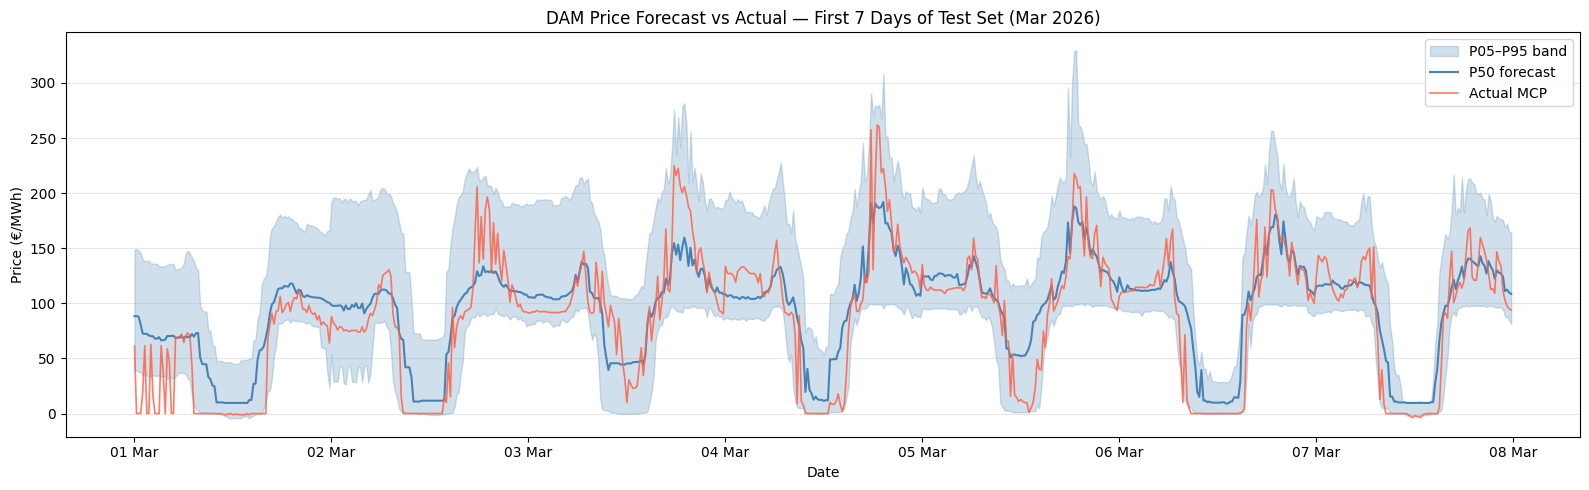

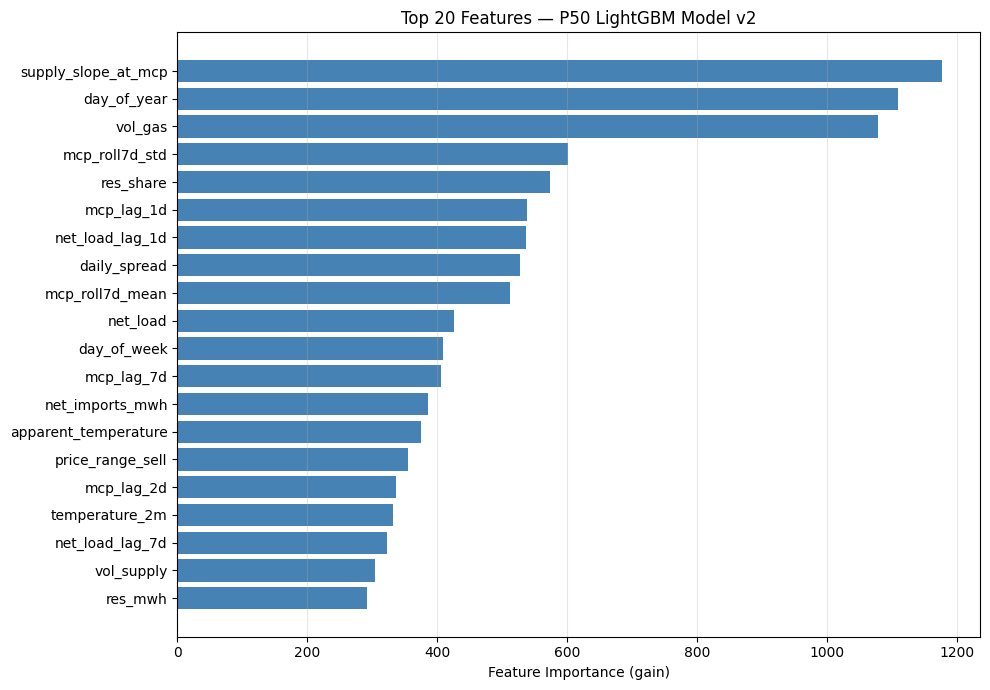

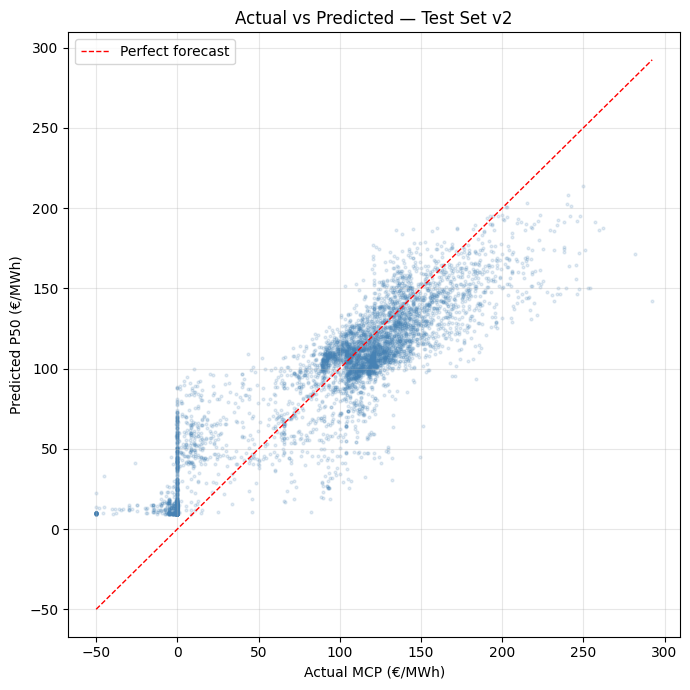


All plots saved to /content/drive/MyDrive/battery-opt/feature-store


In [62]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def compute_sample_weights(y: pd.Series) -> np.ndarray:
    weights = np.ones(len(y))
    weights[y < 20]  = 3.0
    weights[y < 0]   = 5.0
    weights[y > 200] = 2.0
    return weights

sample_weights = compute_sample_weights(y_train)

print(f"Sample weight distribution:")
print(f"  Normal (1x)  : {(sample_weights == 1.0).sum():,} rows")
print(f"  Low price (3x): {(sample_weights == 3.0).sum():,} rows")
print(f"  Negative (5x) : {(sample_weights == 5.0).sum():,} rows")
print(f"  Spike (2x)    : {(sample_weights == 2.0).sum():,} rows")

PARAMS_P50 = {
    'objective': 'quantile', 'alpha': 0.5,
    'boosting_type': 'gbdt', 'n_estimators': 3000,
    'learning_rate': 0.02, 'num_leaves': 128,
    'max_depth': -1, 'min_child_samples': 20,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 0.1,
    'n_jobs': -1, 'random_state': 42, 'verbose': -1,
}
PARAMS_P95 = {
    'objective': 'quantile', 'alpha': 0.95,
    'boosting_type': 'gbdt', 'n_estimators': 5000,
    'learning_rate': 0.01, 'num_leaves': 64,
    'max_depth': 6, 'min_child_samples': 100,
    'subsample': 0.7, 'colsample_bytree': 0.7,
    'reg_alpha': 2.0, 'reg_lambda': 5.0,
    'n_jobs': -1, 'random_state': 42, 'verbose': -1,
}
PARAMS_P05 = {
    'objective': 'quantile', 'alpha': 0.05,
    'boosting_type': 'gbdt', 'n_estimators': 3000,
    'learning_rate': 0.015, 'num_leaves': 64,
    'max_depth': 8, 'min_child_samples': 50,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 1.0, 'reg_lambda': 1.0,
    'n_jobs': -1, 'random_state': 42, 'verbose': -1,
}

models = {}
for label, params in [('p05', PARAMS_P05), ('p50', PARAMS_P50), ('p95', PARAMS_P95)]:
    print(f"\nTraining {label} model (alpha={params['alpha']})...")
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        sample_weight = sample_weights,
        eval_set      = [(X_val, y_val)],
        eval_metric   = 'quantile',
        callbacks     = [
            lgb.early_stopping(stopping_rounds=150, verbose=False),
            lgb.log_evaluation(period=500),
        ],
    )
    models[label] = model
    print(f"  Best iteration : {model.best_iteration_}")
    print(f"  Best val score : {model.best_score_['valid_0']['quantile']:.4f}")

# ── Evaluate ──────────────────────────────────────────────────────────────────
raw_p05 = models['p05'].predict(X_test)
raw_p50 = models['p50'].predict(X_test)
raw_p95 = models['p95'].predict(X_test)

adj_p50 = raw_p50
adj_p05 = np.minimum(raw_p05, adj_p50)
adj_p95 = np.maximum(raw_p95, adj_p50)

preds = pd.DataFrame({
    'datetime': test['datetime'].values,
    'actual':   y_test.values,
    'p05':      adj_p05,
    'p50':      adj_p50,
    'p95':      adj_p95,
})

mae        = mean_absolute_error(preds['actual'], preds['p50'])
rmse       = mean_squared_error(preds['actual'],  preds['p50']) ** 0.5
mae_pct    = (mae / preds['actual'].abs().mean()) * 100
coverage   = ((preds['actual'] >= preds['p05']) &
              (preds['actual'] <= preds['p95'])).mean() * 100
band_width = (preds['p95'] - preds['p05']).mean()

# Breakdown by price regime
neg_mask    = preds['actual'] < 0
low_mask    = (preds['actual'] >= 0)  & (preds['actual'] < 20)
normal_mask = (preds['actual'] >= 20) & (preds['actual'] < 200)
spike_mask  = preds['actual'] >= 200

print(f"\n{'='*50}")
print(f"TEST SET METRICS")
print(f"{'='*50}")
print(f"MAE              : {mae:.2f} €/MWh")
print(f"RMSE             : {rmse:.2f} €/MWh")
print(f"MAE%             : {mae_pct:.1f}%")
print(f"P05-P95 coverage : {coverage:.1f}%  (target ~80%)")
print(f"Avg band width   : {band_width:.1f} €/MWh")
print(f"\nMAE by price regime:")
for mask, label in [(neg_mask,'Negative (<0)'), (low_mask,'Low (0-20)'),
                    (normal_mask,'Normal (20-200)'), (spike_mask,'Spike (>200)')]:
    if mask.sum() > 0:
        regime_mae = mean_absolute_error(preds.loc[mask,'actual'], preds.loc[mask,'p50'])
        print(f"  {label:20s}: {regime_mae:.1f} €/MWh  ({mask.sum()} slots)")

# ── Plot 1: 7-day forecast sample ─────────────────────────────────────────────
sample = preds.iloc[:672]
fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(sample['datetime'], sample['p05'], sample['p95'],
                alpha=0.25, color='steelblue', label='P05–P95 band')
ax.plot(sample['datetime'], sample['p50'],
        color='steelblue', linewidth=1.5, label='P50 forecast')
ax.plot(sample['datetime'], sample['actual'],
        color='tomato', linewidth=1.2, alpha=0.85, label='Actual MCP')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.set_xlabel('Date')
ax.set_ylabel('Price (€/MWh)')
ax.set_title('DAM Price Forecast vs Actual — First 7 Days of Test Set (Mar 2026)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'forecast_test_sample_v2.png', dpi=150)
plt.show()

# ── Plot 2: Feature importance ────────────────────────────────────────────────
importance = pd.DataFrame({
    'feature':    FEATURES,
    'importance': models['p50'].feature_importances_,
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 20 Features — P50 LightGBM Model v2')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance_v2.png', dpi=150)
plt.show()

# ── Plot 3: Actual vs Predicted scatter ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(preds['actual'], preds['p50'],
           alpha=0.15, s=4, color='steelblue')
lims = [preds[['actual','p50']].min().min(),
        preds[['actual','p50']].max().max()]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect forecast')
ax.set_xlabel('Actual MCP (€/MWh)')
ax.set_ylabel('Predicted P50 (€/MWh)')
ax.set_title('Actual vs Predicted — Test Set v2')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'actual_vs_predicted_v2.png', dpi=150)
plt.show()

print(f"\nAll plots saved to {OUT_DIR}")

##Export Model

In [63]:
import pickle

# Save all three models
for label, model in models.items():
    model_path = OUT_DIR / f'lgbm_{label}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved → lgbm_{label}.pkl")

# Save predictions for the test set (useful for backtesting later)
preds.to_csv(OUT_DIR / 'test_predictions.csv', index=False)
print(f"Saved → test_predictions.csv")

# Save feature list — needed to reconstruct inputs for inference
import json
with open(OUT_DIR / 'feature_list.json', 'w') as f:
    json.dump(FEATURES, f)
print(f"Saved → feature_list.json")

print(f"\nModel summary:")
print(f"  P05 best iteration : {models['p05'].best_iteration_}")
print(f"  P50 best iteration : {models['p50'].best_iteration_}")
print(f"  P95 best iteration : {models['p95'].best_iteration_}")
print(f"  Features used      : {len(FEATURES)}")
print(f"  Test MAE           : 20.14 €/MWh")
print(f"  Test coverage      : 83.4%")

Saved → lgbm_p05.pkl
Saved → lgbm_p50.pkl
Saved → lgbm_p95.pkl
Saved → test_predictions.csv
Saved → feature_list.json

Model summary:
  P05 best iteration : 235
  P50 best iteration : 115
  P95 best iteration : 917
  Features used      : 48
  Test MAE           : 20.14 €/MWh
  Test coverage      : 83.4%
